# Notebook Dedicated to Study the Directional Pattern of the Solar Candidates

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import glob

# Load Data

## Load the ntuple Info

In [26]:
main_dir = '/home/joankl/data/solars/real_data/bisMSB/first_candidates/analysis*/resume_files/'
obs_list_ntuple = ['eventID', 'energy_corrected', 'posr_av']
obs_dict_ntuple = {var_i: np.array([]) for var_i in obs_list_ntuple}

for obs_i in obs_list_ntuple:
    flist = glob.glob(main_dir + obs_i + '.npy') # List of directories where the obs is

    for f_i in flist:
        array_i = np.load(f_i)
        obs_dict_ntuple[obs_i] = np.append(obs_dict_ntuple[obs_i], array_i)

# Apply Cut
en_cut = 5.0

condition = (obs_dict_ntuple['energy_corrected'] >= en_cut)

evtid_ntuple = obs_dict_ntuple['eventID'][condition]
energy = obs_dict_ntuple['energy_corrected'][condition]

## Load the RATDS Info

In [79]:
main_dir = '/home/joankl/data/solars/real_data/bisMSB/first_candidates/np_files/'
obs_list_ratds = ['cos_alpha', 'evtid', 'energy', 'posr']
obs_dict_ratds = {var_i: np.array([]) for var_i in obs_list_ratds}

for obs_i in obs_list_ratds:
    flist = glob.glob(main_dir + obs_i + '*.npy')

    for f_i in flist:
        array_i = np.load(f_i)
        obs_dict_ratds[obs_i] = np.append(obs_dict_ratds[obs_i], array_i)

cos_alpha = obs_dict_ratds['cos_alpha']
energy = obs_dict_ratds['energy']
posr = obs_dict_ratds['posr']
evtid_ratds = obs_dict_ratds['evtid']

In [83]:
min(energy)

np.float64(4.859159469604492)

In [71]:
position

array([-1516.12268066, -1891.31225586,  4560.03271484, ...,
       -1388.20336914,  3291.97631836,  3961.71484375], shape=(294318,))

# Extract the Unique eventID (non per hit)

In [56]:
evIDi_unique = []  #Empty list to be filled with the unique (non-redundant) values of the initial evIDs. len(evIDi_unique) = Nº of events

N_data = len(evtid_ratds)
indices_to_delete = [] #Indiced to remove from the observable arrays due to nhits cut

# ----- Calculation of Data break due to repeated non-perhit observales -----
data_break_mask = (np.diff(evtid_ratds) != 0)
data_break_index = np.where(data_break_mask)[0]+1
data_break_index = np.concatenate(([0], data_break_index, [N_data])) # Add the initial and last index

N_terms = len(data_break_index)

for i_dx in range(N_terms - 1):
    init_i = data_break_index[i_dx]
    final_i = data_break_index[i_dx + 1]
    evIDi_unique.append(evtid_ratds[init_i: final_i][0])

In [58]:
len(evIDi_unique)

192

In [59]:
len(evtid_ntuple)

192

# Re-structure the per hit observable

Create 2D arrays: One dimension is the event, and the other is the recorded data. Apply this for the cos(alpha)

# Directionality Plot

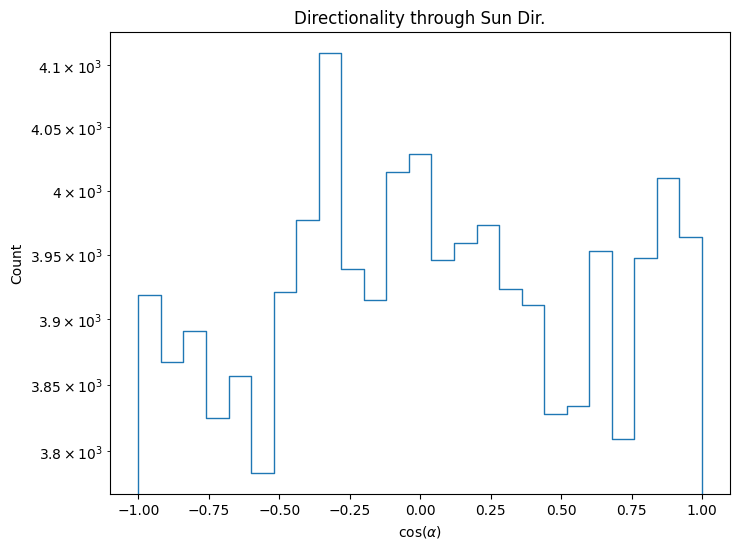

In [14]:
plt.figure(figsize = (8,6))
sn.histplot(cos_alpha, bins = 25, element='step', alpha=0)
plt.yscale('log')
plt.xlabel(r'cos($\alpha$)')
plt.title('Directionality through Sun Dir.')
plt.show()

#### Comments:
There are clear contributions different from solar neutrino events. Lets see the correlation with position and energy